# Notebook 2: TF-IDF + Logistic Regression (Baseline)

Dataset: McAuley-Lab/Amazon-Reviews-2023 — Pet Supplies

This notebook trains a TF-IDF + Logistic Regression classifier on the cleaned
data produced by Notebook 1. Its predictions feed into two business insights
in Notebook 4: **complaint urgency** and **product-specific negative keywords**.
Do not rerun Notebook 1 before this — it reads directly from `data/cleaned_reviews.csv`.

## 1. Imports & Configuration

In [1]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, accuracy_score, ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline
import joblib

warnings.filterwarnings("ignore")

# ── Paths ─────────────────────────────────────────────────────────────────
# Reads from Notebook 1 output — do not change this path
CLEAN_PATH = Path("data/cleaned_reviews.csv")
MODEL_PATH = Path("models/tfidf_logreg.pkl")
MODEL_PATH.parent.mkdir(exist_ok=True)

LABELS      = ["Negative", "Neutral", "Positive"]
LABEL_INT   = {"Negative": 0, "Neutral": 1, "Positive": 2}
INT_LABEL   = {0: "Negative", 1: "Neutral", 2: "Positive"}
RANDOM_SEED = 42


## 2. Load Cleaned Data

In [2]:
df = pd.read_csv(CLEAN_PATH)
df["sentiment_int"] = df["sentiment_label"].map(LABEL_INT)

print(f"Records loaded : {len(df):,}")
print(f"Columns        : {df.columns.tolist()}")
print()
print("Label distribution:")
print(df["sentiment_label"].value_counts().to_string())


Records loaded : 10,000
Columns        : ['rating', 'title', 'text', 'asin', 'parent_asin', 'helpful_vote', 'verified_purchase', 'timestamp', 'review_text', 'sentiment_label', 'sentiment_int', 'word_count', 'datetime', 'year']

Label distribution:
sentiment_label
Positive    7805
Negative    1380
Neutral      815


## 3. Train / Test Split

In [3]:
X = df["review_text"].fillna("").astype(str)
y = df["sentiment_int"]

# Stratified split preserves class proportions in both sets.
# random_state=42 matches Notebook 3 so both models are evaluated
# on the identical test set — required for a fair comparison.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_SEED)

print(f"Train : {len(X_train):,}  |  Test : {len(X_test):,}")
print(f"Train label counts : {pd.Series(y_train).value_counts().to_dict()}")
print(f"Test  label counts : {pd.Series(y_test).value_counts().to_dict()}")


Train : 8,000  |  Test : 2,000
Train label counts : {2: 6244, 0: 1104, 1: 652}
Test  label counts : {2: 1561, 0: 276, 1: 163}


## 4. Build & Train Pipeline

In [4]:
# ── TF-IDF configuration ────────────────────────────────────────────────────
# max_features=20,000 : vocabulary cap balancing coverage vs. noise
# ngram_range=(1,2)   : unigrams + bigrams capture phrases like "not good"
# sublinear_tf=True   : log-scale TF dampens high-frequency terms
# min_df=2            : discard terms appearing in fewer than 2 documents
tfidf = TfidfVectorizer(
    max_features=20_000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2,
    strip_accents="unicode",
    analyzer="word",
)

# ── Logistic Regression ─────────────────────────────────────────────────────
# class_weight='balanced' counteracts the 78% positive skew so the model
# does not default to predicting Positive for everything.
lr = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    C=1.0,
    solver="lbfgs",
    multi_class="multinomial",
    random_state=RANDOM_SEED,
)

pipeline = Pipeline([("tfidf", tfidf), ("clf", lr)])
pipeline.fit(X_train, y_train)
print("Pipeline trained successfully.")


Pipeline trained successfully.


## 5. Evaluation

In [5]:
y_pred = pipeline.predict(X_test)

print("CLASSIFICATION REPORT — TF-IDF + Logistic Regression")
print("=" * 55)
print(classification_report(y_test, y_pred,
                             target_names=LABELS,
                             zero_division=0))

macro_f1    = f1_score(y_test, y_pred, average="macro",     zero_division=0)
weighted_f1 = f1_score(y_test, y_pred, average="weighted",  zero_division=0)
acc         = accuracy_score(y_test, y_pred)

print(f"Macro F1    : {macro_f1:.4f}")
print(f"Weighted F1 : {weighted_f1:.4f}")
print(f"Accuracy    : {acc:.4f}")


CLASSIFICATION REPORT — TF-IDF + Logistic Regression
              precision    recall  f1-score   support

    Negative       0.66      0.71      0.69       276
     Neutral       0.33      0.50      0.40       163
    Positive       0.95      0.89      0.92      1561

    accuracy                           0.83      2000
   macro avg       0.65      0.70      0.67      2000
weighted avg       0.86      0.83      0.85      2000

Macro F1    : 0.6678
Weighted F1 : 0.8457
Accuracy    : 0.8335


### 5.1 Confusion Matrix

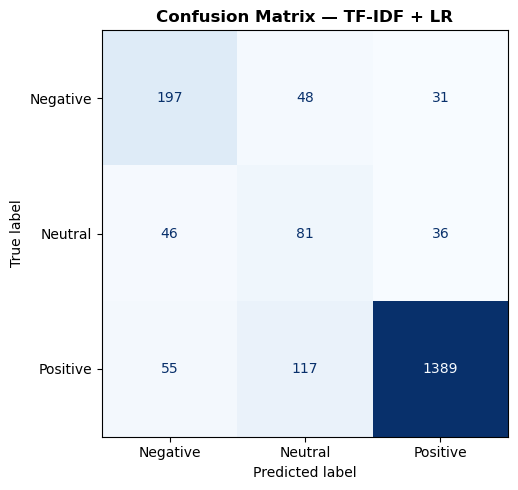

In [6]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABELS).plot(
    ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix — TF-IDF + LR", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("data/fig_cm_tfidf.png", dpi=150, bbox_inches="tight")
plt.show()


### 5.2 Cross-Validation

In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
cv_scores = cross_val_score(pipeline, X, y,
                             cv=cv, scoring="f1_macro", n_jobs=-1)
print(f"5-Fold CV Macro F1 : {cv_scores.round(4)}")
print(f"Mean : {cv_scores.mean():.4f}  |  Std : {cv_scores.std():.4f}")


5-Fold CV Macro F1 : [0.6623 0.671  0.6697 0.6996 0.6815]
Mean : 0.6768  |  Std : 0.0129


### 5.3 Top Predictive Terms per Class
These term coefficients are used directly in Notebook 4 to identify
product-specific language driving negative reviews.

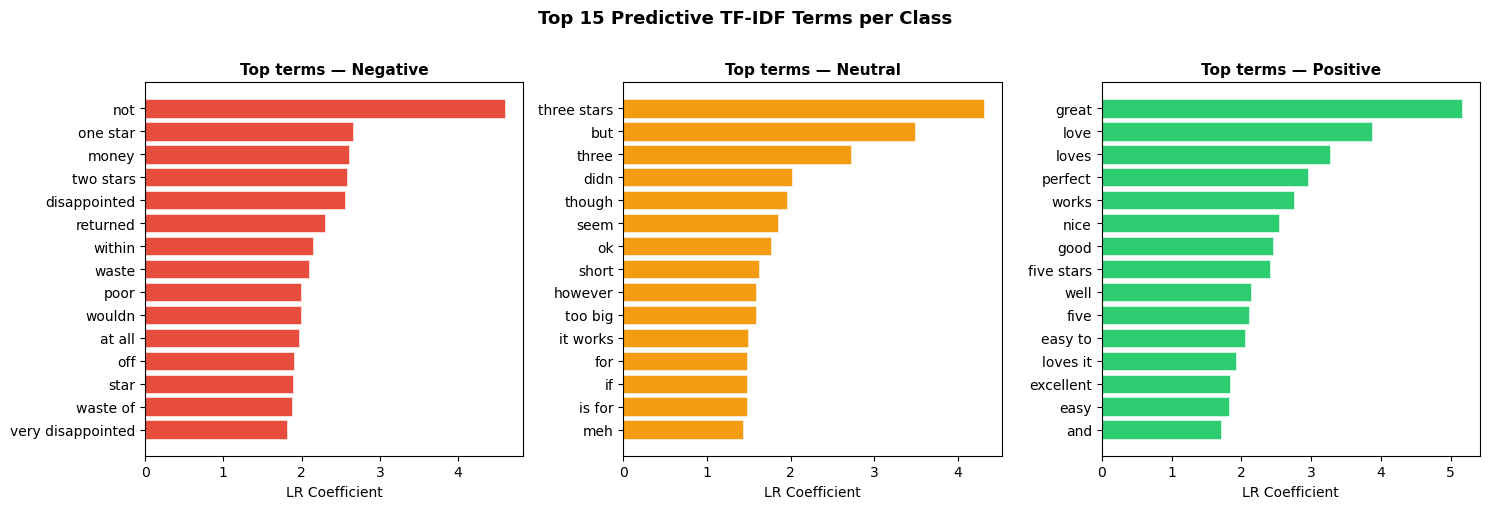

In [8]:
feature_names = np.array(pipeline.named_steps["tfidf"].get_feature_names_out())
coef          = pipeline.named_steps["clf"].coef_

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colours = {"Negative": "#E74C3C", "Neutral": "#F39C12", "Positive": "#2ECC71"}

for i, label in enumerate(LABELS):
    top_idx   = np.argsort(coef[i])[-15:][::-1]
    top_terms = feature_names[top_idx]
    top_coefs = coef[i][top_idx]
    axes[i].barh(top_terms[::-1], top_coefs[::-1],
                 color=colours[label], edgecolor="white", linewidth=0.4)
    axes[i].set_title(f"Top terms — {label}", fontsize=11, fontweight="bold")
    axes[i].set_xlabel("LR Coefficient")

plt.suptitle("Top 15 Predictive TF-IDF Terms per Class",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("data/fig_tfidf_terms.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Save Model & Predictions

In [9]:
# Save trained pipeline for reference
joblib.dump(pipeline, MODEL_PATH)
print(f"Model saved → {MODEL_PATH}")

# Attach TF-IDF predictions to the full dataset
df["tfidf_pred_int"]   = pipeline.predict(X)
df["tfidf_pred_label"] = df["tfidf_pred_int"].map(INT_LABEL)

# Save — Notebook 3 will add RoBERTa predictions on top of this file
df.to_csv("data/cleaned_reviews_with_preds.csv", index=False)
print("Predictions saved → data/cleaned_reviews_with_preds.csv")

print()
print("SUMMARY")
print(f"  Test Macro F1 : {macro_f1:.4f}")
print(f"  Test Accuracy : {acc:.4f}")
print(f"  5-Fold CV F1  : {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")


Model saved → models\tfidf_logreg.pkl
Predictions saved → data/cleaned_reviews_with_preds.csv

SUMMARY
  Test Macro F1 : 0.6678
  Test Accuracy : 0.8335
  5-Fold CV F1  : 0.6768 (±0.0129)
